In [ ]:
# MODELLO 5: recettori + osmosi con saturazione


import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
import pandas as pd

# Impostazione dello stile grafico
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [26]:
# --- PARAMETRI FISICI ---
# Radionuclide di esempio: Lutezio-177 (177Lu)
T_half = 160.8  # Emivita fisica in ore (~6.7 giorni)
lmbda = np.log(2) / T_half  # Costante di decadimento fisico (h^-1)

# --- PARAMETRI ---
k0 = 1      # Costante dissociazione (h^-1) -> k-1
k1 = 0.1    # Costante di associazione (h^-1) -> cR*k1 negli appunti
k2 = 1      # Costante di internalizzazione tramite proteine (h^-1)
k3 = 0.01      # Costante di internalizzazione tramite osmosi (h^-1)

# --- PARAMETRI DELLA COLTURA ---
A0 = 1.0       # Attività iniziale iniettata nel terreno di coltura (kBq)
B_max = 0.01    # Attività massima sulla membrana (kBq)

In [27]:
def cellular_kinetic_system(t, y, lmbda, k0, k1, k2, k3, B_max):
    """
    Sistema ODE per la cinetica del radiofarmaco in vitro.
    y = [Am, Ab, Aint]
    """
    Am, Ab, Aint, Adec = y
    
    # Frazione di recettori di membrana ancora liberi (0 <= ratio <= 1)
    free_receptor_ratio = max(0.0, 1.0 - Ab / B_max)
    k1_eff = k1 * free_receptor_ratio

    # Equazioni differenziali del sistema
    dAm_dt = k0 * Ab - (lmbda + k3) * Am - k1_eff * Am
    dAb_dt = k1_eff * Am - (lmbda + k0 + k2) * Ab
    dAint_dt = -lmbda * Aint + k2 * Ab + k3 * Am
    dAdec_dt = lmbda * (Am + Ab + Aint)
    
    return [dAm_dt, dAb_dt, dAint_dt, dAdec_dt]

# Condizioni iniziali: tutta l'attivita e inizialmente nel terreno Am(0) = A0
y0 = [A0, 0.0, 0.0, 0.0]

# Intervallo temporale di simulazione (es. 72 ore)
t_span = (0, 144)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Risoluzione del sistema ODE (metodo RK45)
sol = solve_ivp(
    cellular_kinetic_system, 
    t_span, 
    y0, 
    t_eval=t_eval, 
    args=(lmbda, k0, k1, k2, k3, B_max),
    method='RK45'
)

# Estrazione dei risultati
t = sol.t
Am, Ab, Aint, Adec = sol.y
A_cell_total = Ab + Aint  # Attività totale accumulata dalla cellula (membrana + internalizzata)
A_tot = Am + Ab + Aint + Adec

# Calcolo dell'Attività Cumulata A_tilde (integrale dell'attività nel tempo)
cumulated_activity_cell = np.trapezoid(A_cell_total, t)  # in kBq*h

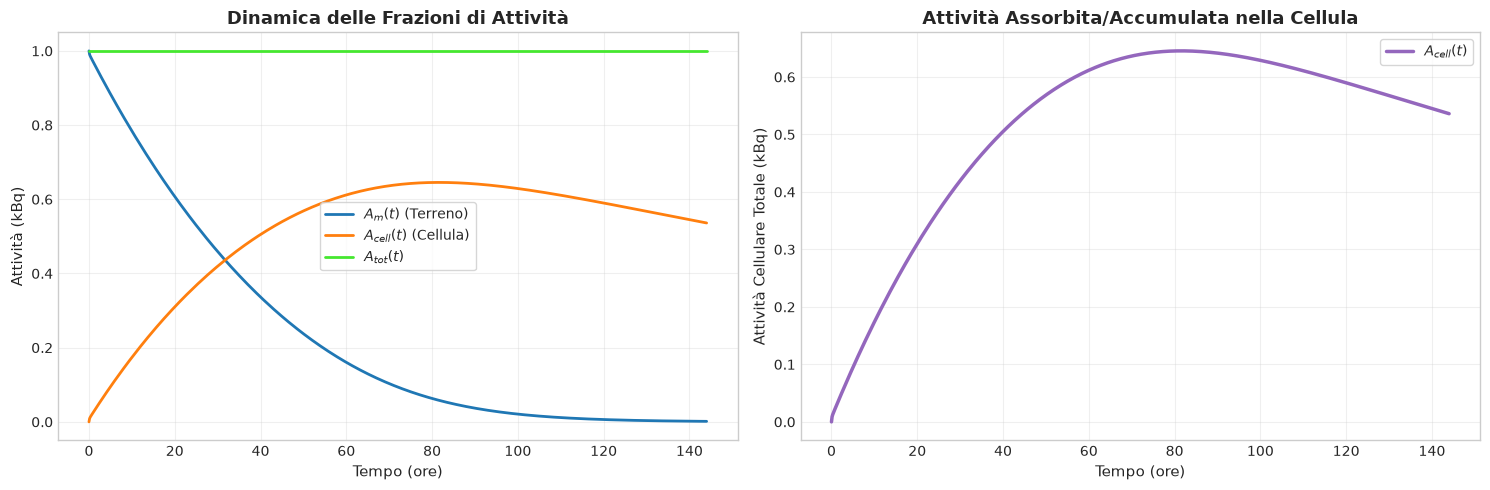

--------------------------------------------------
Attività Cumulata Cellulare Integrata (0-144h): 74.19 kBq·h
--------------------------------------------------


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: Cinetica nei tre compartimenti
axes[0].plot(t, Am, label='$A_m(t)$ (Terreno)', color='#1f77b4', linewidth=2)
axes[0].plot(t, A_cell_total, label='$A_{cell}(t)$ (Cellula)', color='#ff7f0e', linewidth=2)
axes[0].plot(t, A_tot, label='$A_{tot}(t)$', color="#45e72f", linewidth=2)
axes[0].set_xlabel('Tempo (ore)', fontsize=11)
axes[0].set_ylabel('Attività (kBq)', fontsize=11)
axes[0].set_title('Dinamica delle Frazioni di Attività', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.3)

# Grafico 2: Attività Totale Cellulare e Saturazione
axes[1].plot(t, A_cell_total, label='$A_{cell}(t)$', color='#9467bd', linewidth=2.5)
axes[1].set_xlabel('Tempo (ore)', fontsize=11)
axes[1].set_ylabel('Attività Cellulare Totale (kBq)', fontsize=11)
axes[1].set_title('Attività Assorbita/Accumulata nella Cellula', fontsize=13, fontweight='bold')
axes[1].legend(frameon=True)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stampa dell'attività cumulata
print(f"--------------------------------------------------")
print(f"Attività Cumulata Cellulare Integrata (0-{t_span[1]}h): {cumulated_activity_cell:.2f} kBq·h")
print(f"--------------------------------------------------")

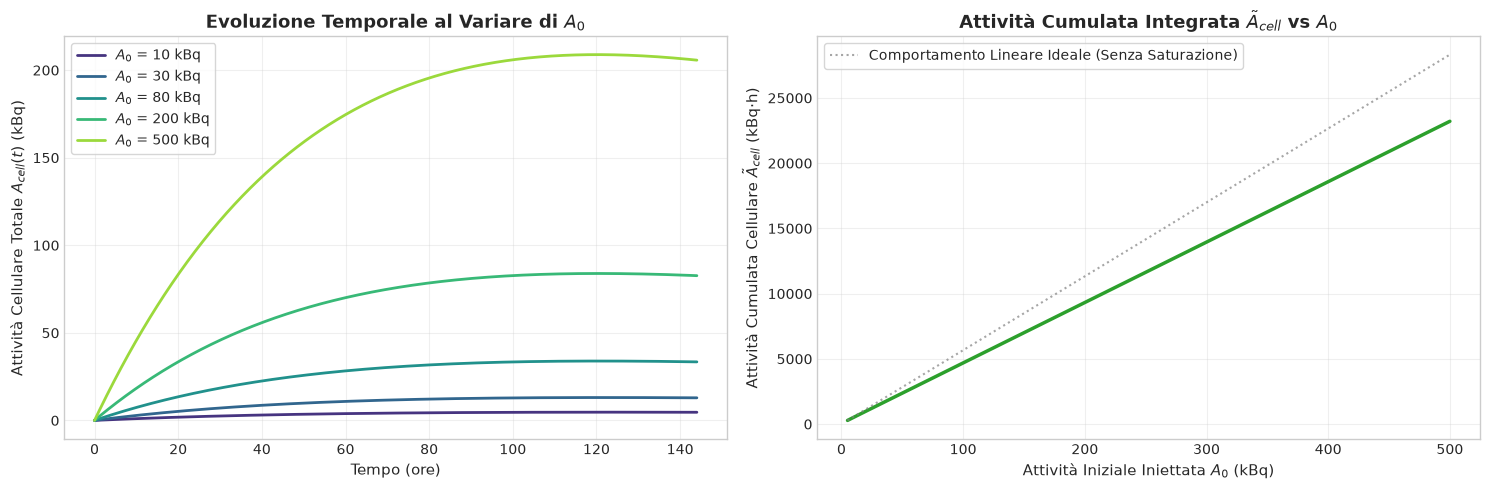

In [29]:
A0_range = np.linspace(5, 500, 60)  # Variazione di A0 da 5 a 500 kBq

cumulated_A_list = []
max_A_cell_list = []

for A0_i in A0_range:
    # Risoluzione ODE per il generico A0_i
    y0_i = [A0_i, 0.0, 0.0, 0.0]
    sol_i = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        y0_i, 
        t_eval=t_eval, 
        args=(lmbda, k0, k1, k2, k3, B_max),
        method='RK45'
    )
    
    A_cell_i = sol_i.y[1] + sol_i.y[2]  # Ab + Aint
    
    # Salviamo il picco massimo e l'attività cumulata integrata (proporzionale alla dose)
    max_A_cell_list.append(np.max(A_cell_i))
    cumulated_A_list.append(np.trapezoid(A_cell_i, sol_i.t))

# --- VISUALIZZAZIONE GRAFICA ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: Curve temporali A_cell(t) per campioni significativi di A0
A0_samples = [10, 30, 80, 200, 500]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(A0_samples)))

for A0_sample, color in zip(A0_samples, colors):
    sol_sample = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        [A0_sample, 0.0, 0.0, 0.0], 
        t_eval=t_eval, 
        args=(lmbda, k0, k1, k2, k3, B_max),
        method='RK45'
    )
    A_cell_sample = sol_sample.y[1] + sol_sample.y[2]
    axes[0].plot(sol_sample.t, A_cell_sample, label=f'$A_0$ = {A0_sample} kBq', color=color, linewidth=2)

axes[0].set_xlabel('Tempo (ore)', fontsize=11)
axes[0].set_ylabel('Attività Cellulare Totale $A_{cell}(t)$ (kBq)', fontsize=11)
axes[0].set_title('Evoluzione Temporale al Variare di $A_0$', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.3)

# Grafico 2: Attività Cumulata vs A0 (Curva di Saturazione)
axes[1].plot(A0_range, cumulated_A_list, color='#2ca02c', linewidth=2.5)
axes[1].set_xlabel('Attività Iniziale Iniettata $A_0$ (kBq)', fontsize=11)
axes[1].set_ylabel('Attività Cumulata Cellulare $\\tilde{A}_{cell}$ (kBq·h)', fontsize=11)
axes[1].set_title('Attività Cumulata Integrata $\\tilde{A}_{cell}$ vs $A_0$', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Evidenziamo visivamente la deviazione dalla linearità
linear_trend = cumulated_A_list[0] / A0_range[0] * A0_range
axes[1].plot(A0_range, linear_trend, color='gray', linestyle=':', alpha=0.7, label='Comportamento Lineare Ideale (Senza Saturazione)')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

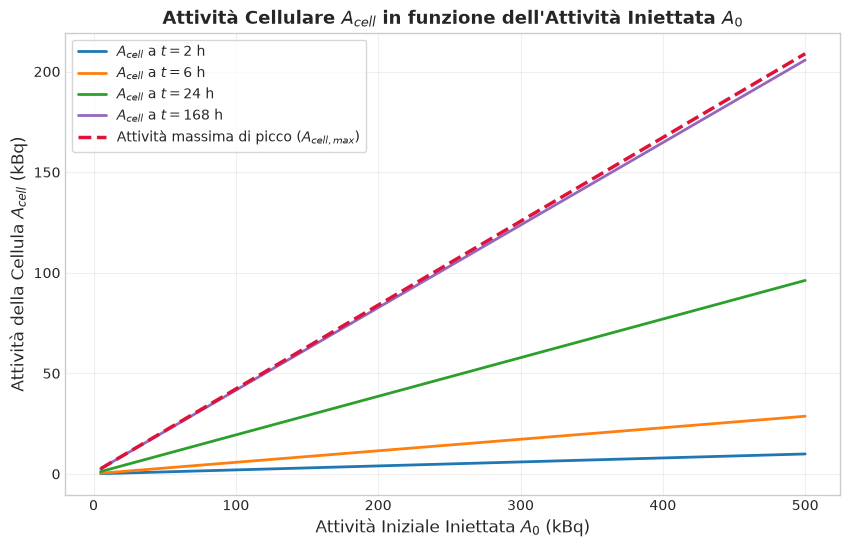

In [30]:
# --- PARAMETRIC SWEEP: A_cell vs A_0 ---
A0_range = np.linspace(5, 500, 100)  # Variazione continua dell'attività iniettata A0

# Tempi specifici a cui estrarre l'attività cellulare (in ore)
time_points = [2, 6, 24, 168]

# Dizionari e liste per raccogliere i dati
A_cell_at_times = {t_val: [] for t_val in time_points}
A_cell_max = []

for A0_i in A0_range:
    y0_i = [A0_i, 0.0, 0.0, 0.0]
    sol_i = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        y0_i, 
        t_eval=t_eval, 
        args=(lmbda, k0, k1, k2, k3, B_max),
        method='RK45'
    )
    
    A_cell_i = sol_i.y[1] + sol_i.y[2]  # A_cell(t) = Ab(t) + Aint(t)
    
    # Estraggo A_cell ai tempi prefissati
    for t_val in time_points:
        idx = np.argmin(np.abs(sol_i.t - t_val))  # Indice dell'istante t più vicino
        A_cell_at_times[t_val].append(A_cell_i[idx])
        
    # Estraggo il picco massimo assoluto di A_cell
    A_cell_max.append(np.max(A_cell_i))

# --- VISUALIZZAZIONE GRAFICA ---
plt.figure(figsize=(10, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

# Curve di A_cell(A0) ai vari tempi
for t_val, color in zip(time_points, colors):
    plt.plot(A0_range, A_cell_at_times[t_val], 
             label=f'$A_{{cell}}$ a $t = {t_val}$ h', 
             color=color, linewidth=2)

# Curva del picco massimo A_cell_max(A0)
plt.plot(A0_range, A_cell_max, 
         label='Attività massima di picco ($A_{cell, max}$)', 
         color='crimson', linestyle='--', linewidth=2.5)

# Formattazione grafico
plt.xlabel('Attività Iniziale Iniettata $A_0$ (kBq)', fontsize=12)
plt.ylabel('Attività della Cellula $A_{cell}$ (kBq)', fontsize=12)
plt.title('Attività Cellulare $A_{cell}$ in funzione dell\'Attività Iniettata $A_0$', fontsize=13, fontweight='bold')
plt.legend(frameon=True, fontsize=10)
plt.grid(True, alpha=0.3)

plt.show()

          RISULTATI DEL FIT SUI DATI REALI        
k0_f (Dissociazione k_off) : 1.045816e-01 ± 5.532589e-02 h^-1
k1_f (Associazione k_on)   : 4.035537e-04 ± 1.040701e-04 h^-1
k2_f (Int. Proteica)       : 1.000000e-06 ± 1.170275e-02 h^-1
k3_f (Int. Osmotica)       : 1.000000e-08 ± 1.940864e-05 h^-1
B_max_f (Saturazione Memb) : 6.071515e-01 ± 2.877045e-01 Bq/cellula
--------------------------------------------------
Chi-quadro Totale (Chi2)   : 3.9416
Gradi di libertà (dof)     : 4
Chi-quadro Ridotto         : 0.9854


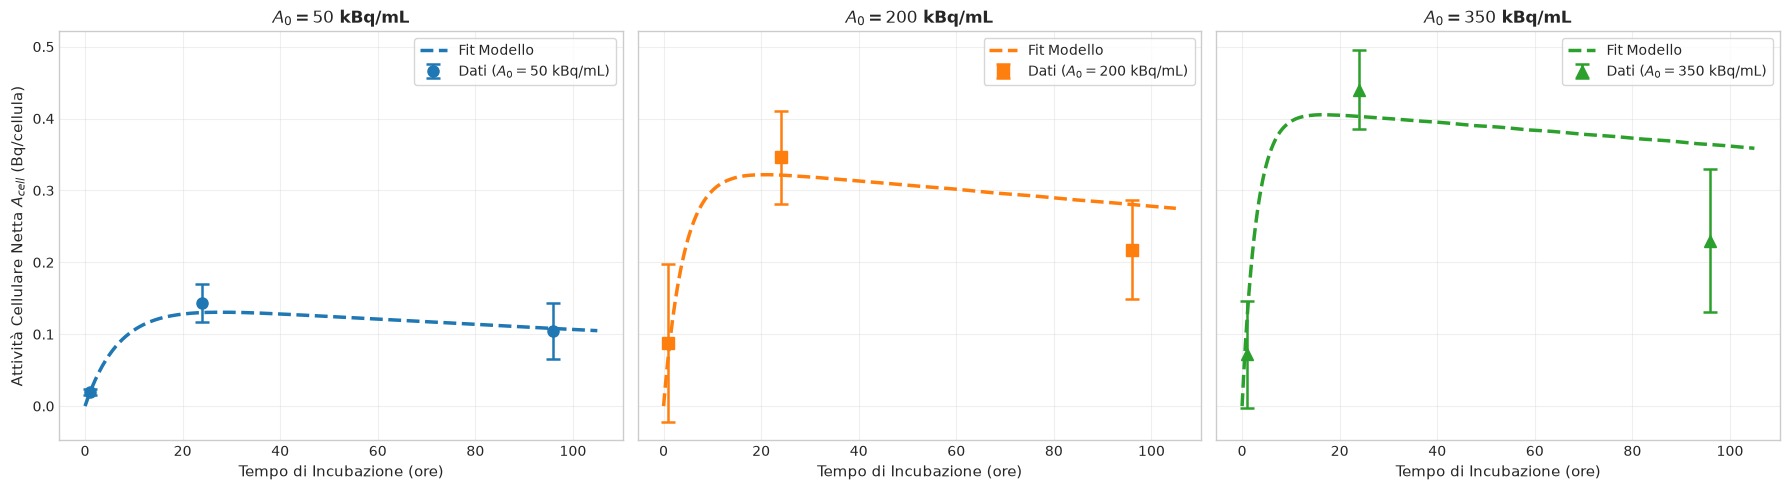

In [42]:
# =============================================================================
# 1. STRUTTURAZIONE DATI SPERIMENTALI
# =============================================================================
# Tempi di incubazione (ore)
t_exp = np.array([1.0, 24.0, 96.0])

# Attività iniettate A0 (kBq/mL)
A0_exp = np.array([50.0, 200.0, 350.0])

# Rumore di fondo misurato a A0 = 0 (Bq/cellula)
bg = np.array([0.004199309, 0.003368672, 0.000942459])

# Matrice Attività Cellulare Misurata A_int_raw (Bq/cellula)
# Righe: A0 (50, 200, 350 kBq/mL) | Colonne: Tempi (1h, 24h, 96h)
A_int_raw = np.array([
    [0.023594163, 0.146368766, 0.105341900],  # A0 = 50
    [0.092211399, 0.349493079, 0.218233662],  # A0 = 200
    [0.076153440, 0.443769956, 0.231148121]   # A0 = 350
])

# Matrice delle Incertezze Sperimentali (err)
err_matrix = np.array([
    [0.004641692, 0.026652162, 0.039304734],  # A0 = 50
    [0.109901502, 0.064321945, 0.068945026],  # A0 = 200
    [0.074465535, 0.055049521, 0.099395703]   # A0 = 350
])

# Sottrazione del fondo per ottenere l'attività netta internalizzata
A_int_net = np.maximum(A_int_raw - bg, 1e-6)

# Parametro fisico: Emivita radionuclide in ore
# IMPO: Modifica T_half con l'emivita esatta del radionuclide usato nel tuo esperimento!
T_half = 7.4 * 24
lmbda = np.log(2) / T_half

# =============================================================================
# 2. MODELLO ODE E RESIDUI PESATI (CHI-QUADRO)
# =============================================================================
def model_predictions(params, t_points, A0_values):
    """Risolve il sistema ODE per le varie concentrazioni A0."""
    k0, k1, k2, k3, B_max = params

    def ode_system(t, y):
        Am, Ab, Aint = y  # Spacchettamento corretto all'inizio della funzione!
        
        # Rapporto recettori liberi
        free_receptor_ratio = max(0.0, 1.0 - Ab / B_max) if B_max > 0 else 0.0
        k1_eff = k1 * free_receptor_ratio

        dAm_dt = k0 * Ab - (lmbda + k3) * Am - k1_eff * Am
        dAb_dt = k1_eff * Am - (lmbda + k0 + k2) * Ab
        dAint_dt = -lmbda * Aint + k2 * Ab + k3 * Am
        return [dAm_dt, dAb_dt, dAint_dt]

    predictions = []
    t_span = (0, float(np.max(t_points)))
    
    for A0 in A0_values:
        sol = solve_ivp(ode_system, t_span, [A0, 0.0, 0.0], t_eval=t_points, method='RK45')
        # Predizione dell'attività cellulare totale (Ab + Aint)
        predictions.append(sol.y[1] + sol.y[2])
        
    return np.array(predictions)

def weighted_residuals(params, t_points, A0_values, data_matrix, weights_matrix):
    """Calcola i residui pesati: (Pred - Dati) / σ"""
    preds = model_predictions(params, t_points, A0_values)
    return ((preds - data_matrix) / weights_matrix).flatten()

# =============================================================================
# 3. FIT DEI PARAMETRI
# =============================================================================
# Stima iniziale ragionevole per la scala dei dati (Bq/cellula vs kBq/mL)
p0 = [0.01, 1e-5, 0.01, 1e-6, 0.1]

# Limiti sui parametri [k0, k1, k2, k3, B_max]
lower_bounds = [1e-6, 1e-8, 1e-6, 1e-8, 1e-4]
upper_bounds = [2.0,  0.1,  2.0,  0.1,  10.0]

# Fit con Least Squares
res_fit = least_squares(
    weighted_residuals, 
    p0, 
    bounds=(lower_bounds, upper_bounds),
    args=(t_exp, A0_exp, A_int_net, err_matrix),
    method='trf'
)

# Estrazione dei parametri
k0_f, k1_f, k2_f, k3_f, B_max_f = res_fit.x

# Statistica e Covarianza
N = A_int_net.size
p = len(res_fit.x)
dof = N - p

chi2 = np.sum(res_fit.fun**2)
chi2_red = chi2 / dof if dof > 0 else 1.0

J = res_fit.jac
try:
    cov = np.linalg.pinv(J.T @ J)
    param_errors = np.sqrt(np.diagonal(cov) * chi2_red)
except Exception as e:
    param_errors = np.full(p, np.nan)

k0_err, k1_err, k2_err, k3_err, B_max_err = param_errors

# =============================================================================
# 4. RISULTATI E GRAFICI
# =============================================================================
t_smooth = np.linspace(0, 105, 300)
preds_smooth = model_predictions(res_fit.x, t_smooth, A0_exp)

print("==================================================")
print("          RISULTATI DEL FIT SUI DATI REALI        ")
print("==================================================")
print(f"k0_f (Dissociazione k_off) : {k0_f:.6e} ± {k0_err:.6e} h^-1")
print(f"k1_f (Associazione k_on)   : {k1_f:.6e} ± {k1_err:.6e} h^-1")
print(f"k2_f (Int. Proteica)       : {k2_f:.6e} ± {k2_err:.6e} h^-1")
print(f"k3_f (Int. Osmotica)       : {k3_f:.6e} ± {k3_err:.6e} h^-1")
print(f"B_max_f (Saturazione Memb) : {B_max_f:.6e} ± {B_max_err:.6e} Bq/cellula")
print("--------------------------------------------------")
print(f"Chi-quadro Totale (Chi2)   : {chi2:.4f}")
print(f"Gradi di libertà (dof)     : {dof}")
print(f"Chi-quadro Ridotto         : {chi2_red:.4f}")
print("==================================================")

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

# Creiamo una figura con 1 riga e 3 colonne di sottografici
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, A0 in enumerate(A0_exp):
    ax = axes[i]
    
    # Dati sperimentali
    ax.errorbar(t_exp, A_int_net[i], yerr=err_matrix[i], 
                fmt=markers[i], color=colors[i], ecolor=colors[i], elinewidth=1.8,
                capsize=5, capthick=1.8, markersize=8, zorder=5,
                label=f'Dati ($A_0 = {A0:.0f}$ kBq/mL)')
    
    # Curva di fit
    ax.plot(t_smooth, preds_smooth[i], color=colors[i], linestyle='--', linewidth=2.5, 
            label='Fit Modello')

    # Formattazione per singolo pannello
    ax.set_title(f'$A_0 = {A0:.0f}$ kBq/mL', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tempo di Incubazione (ore)', fontsize=11)
    if i == 0:
        ax.set_ylabel('Attività Cellulare Netta $A_{cell}$ (Bq/cellula)', fontsize=11)
    ax.legend(frameon=True, fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2585216/850384976.py:17: SyntaxWarning: invalid escape sequence '\p'
  plt.axhline(2, color='gray', linestyle=':', alpha=0.6, label='Banda $\pm 2\sigma$')
/tmp/ipykernel_2585216/850384976.py:22: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Residui Pesati (Unità di $\sigma$)', fontsize=11)


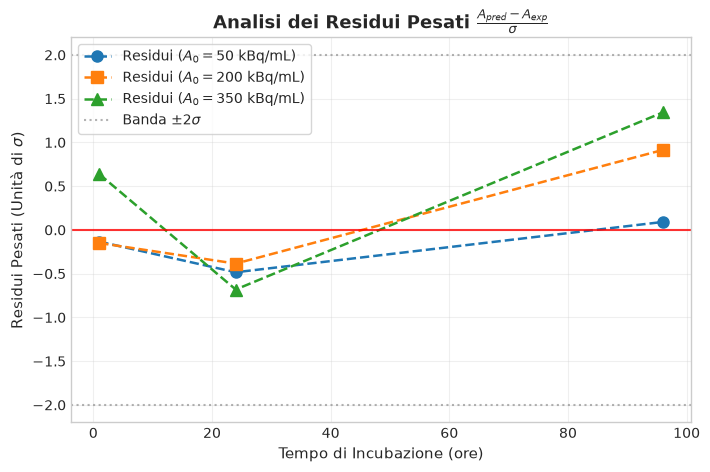

In [43]:
# =============================================================================
# ANALISI DEI RESIDUI PESATI
# =============================================================================

# Calcolo delle predizioni e della matrice dei residui pesati (Pred - Dati) / sigma
preds_net = model_predictions(res_fit.x, t_exp, A0_exp)
residuals_matrix = (preds_net - A_int_net) / err_matrix

plt.figure(figsize=(8, 5))
for i, A0 in enumerate(A0_exp):
    plt.plot(t_exp, residuals_matrix[i], marker=markers[i], color=colors[i], 
             linestyle='--', linewidth=1.8, markersize=8,
             label=f'Residui ($A_0 = {A0:.0f}$ kBq/mL)')

# Linea di riferimento a 0 e bande a +- 2 sigma
plt.axhline(0, color='red', linestyle='-', linewidth=1.5, alpha=0.8)
plt.axhline(2, color='gray', linestyle=':', alpha=0.6, label='Banda $\pm 2\sigma$')
plt.axhline(-2, color='gray', linestyle=':', alpha=0.6)

plt.title('Analisi dei Residui Pesati $\\frac{A_{pred} - A_{exp}}{\\sigma}$', fontsize=13, fontweight='bold')
plt.xlabel('Tempo di Incubazione (ore)', fontsize=11)
plt.ylabel('Residui Pesati (Unità di $\sigma$)', fontsize=11)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

         MATRICE DI CORRELAZIONE PARAMETRI        
Param             k0        k1        k2        k3     B_max
------------------------------------------------------------
k0             1.000     0.710     0.609    -0.532     0.654
k1             0.710     1.000     0.305    -0.289     0.266
k2             0.609     0.305     1.000    -0.964     0.770
k3            -0.532    -0.289    -0.964     1.000    -0.831
B_max          0.654     0.266     0.770    -0.831     1.000


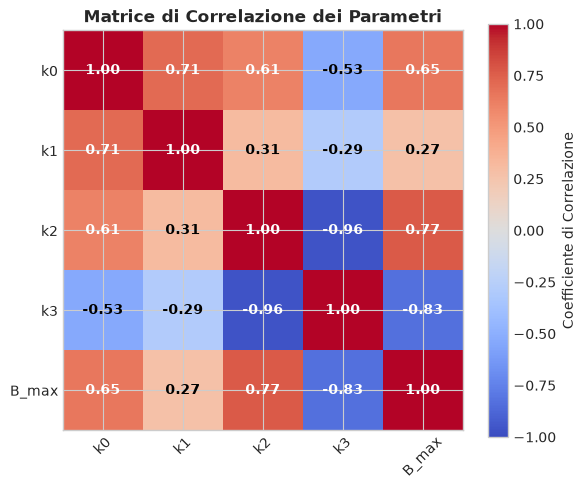

In [45]:
# Derivazione della matrice di correlazione R_ij = Cov_ij / (sigma_i * sigma_j)
stds = np.sqrt(np.diagonal(cov))
corr_matrix = cov / np.outer(stds, stds)

param_names = ['k0', 'k1', 'k2', 'k3', 'B_max']

# Stampa in console
print("==================================================")
print("         MATRICE DI CORRELAZIONE PARAMETRI        ")
print("==================================================")
header = f"{'Param':<10}" + "".join([f"{name:>10}" for name in param_names])
print(header)
print("-" * len(header))
for i, name in enumerate(param_names):
    row = f"{name:<10}" + "".join([f"{corr_matrix[i, j]:>10.3f}" for j in range(len(param_names))])
    print(row)
print("==================================================")

# Visualizzazione via Heatmap
plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Coefficiente di Correlazione')
plt.xticks(range(len(param_names)), param_names, rotation=45)
plt.yticks(range(len(param_names)), param_names)
plt.title('Matrice di Correlazione dei Parametri', fontsize=12, fontweight='bold')

for i in range(len(param_names)):
    for j in range(len(param_names)):
        plt.text(j, i, f"{corr_matrix[i, j]:.2f}", ha='center', va='center',
                 color='white' if abs(corr_matrix[i, j]) > 0.6 else 'black', fontweight='bold')

plt.tight_layout()
plt.show()